# Interaction Tracking Analysis

Code to analyze the output from `interactionTracker.js`: process it to determine the likely interactions and reduce the amount of data, then produce some statistics.

In [1]:
from shared import *
from interactions.helpers import *


# Load (refined) interaction data.
for participant in participants:
    print("\nParticipant " + participant.name)
    filepath = os.getcwd() + f"/interactions/interaction_data/interactions_{participant.name}.json"
    interactionData = loadInteractionData(filepath)
    participant.interactionData = refineInteractionData(interactionData)


Participant P1
Removed 37 invalid interaction entries!
Removed 12 duplicate interaction entries.

Participant P2
Removed 58 invalid interaction entries!

Participant P3
Removed 99 invalid interaction entries!
Removed 44 duplicate interaction entries.

Participant P4
Removed 21 invalid interaction entries!

Participant P5
Removed 165 invalid interaction entries!

Participant P6
Removed 117 invalid interaction entries!
Removed 42 duplicate interaction entries.

Participant P7
Removed 56 invalid interaction entries!

Participant P8
Removed 168 invalid interaction entries!
Removed 2 duplicate interaction entries.

Participant P9
Removed 25 invalid interaction entries!
Removed 3 duplicate interaction entries.


In [2]:
# Map interactions to correct tasks.
for participant in participants:
    interactionsFirstTask, interactionsSecondTask = splitInteractionsByTask(participant.interactionData)

    # only data for one task was tracked -> assume it was for task with extension active
    if not interactionsSecondTask:
        if participant.evalTask == EvaluationTask.T1:
            participant.interactionsTaskOne = interactionsFirstTask
            participant.interactionsTaskTwo = []
        else:
            participant.interactionsTaskOne = []
            participant.interactionsTaskTwo = interactionsFirstTask
    
    # ensure interactions are mapped to correct task
    else:
        if participant.taskOrder == TaskOrder.T1T2:
            participant.interactionsTaskOne = interactionsFirstTask
            participant.interactionsTaskTwo = interactionsSecondTask
        else:
            participant.interactionsTaskOne = interactionsSecondTask
            participant.interactionsTaskTwo = interactionsFirstTask

In [3]:
taskOneWithExtensionCounts = []
taskOneWithoutExtensionCounts = []
taskTwoWithExtensionCounts = []
taskTwoWithoutExtensionCounts = []

taskOneWithExtensionData = []
taskOneWithoutExtensionData = []
taskTwoWithExtensionData = []
taskTwoWithoutExtensionData = []

evaluationCounts = defaultdict(int)
# P9 has nav jumps despite not using extension in T1???
for participant in participants:
    if participant.interactionsTaskOne:
        if participant.evalTask == EvaluationTask.T1:
            taskOneWithExtensionData += participant.interactionsTaskOne
            taskOneWithExtensionCounts.append(countInteractions(participant.interactionsTaskOne))
            evaluationCounts["taskOneWithExtension"] += 1
        else:
            taskOneWithoutExtensionData += participant.interactionsTaskOne
            taskOneWithoutExtensionCounts.append(countInteractions(participant.interactionsTaskOne))
            evaluationCounts["taskOneWithoutExtension"] += 1
    if participant.interactionsTaskTwo:
        if participant.evalTask == EvaluationTask.T2:
            taskTwoWithExtensionData += participant.interactionsTaskTwo
            taskTwoWithExtensionCounts.append(countInteractions(participant.interactionsTaskTwo))
            evaluationCounts["taskTwoWithExtension"] += 1
        else:
            taskTwoWithoutExtensionData += participant.interactionsTaskTwo
            taskTwoWithoutExtensionCounts.append(countInteractions(participant.interactionsTaskTwo))
            evaluationCounts["taskTwoWithoutExtension"] += 1

def combineInteractions(interactionsData):
    combinedInteractions = defaultdict(int)
    for participantData in interactionsData:
        for key, value in participantData.items():
            combinedInteractions[key] += value
    return combinedInteractions


taskOneWithExtension = combineInteractions(taskOneWithExtensionCounts)
taskOneWithoutExtension = combineInteractions(taskOneWithoutExtensionCounts)
taskTwoWithExtension = combineInteractions(taskTwoWithExtensionCounts)
taskTwoWithoutExtension = combineInteractions(taskTwoWithoutExtensionCounts)

print(f"Task one with extension count: {evaluationCounts['taskOneWithExtension']}")
print(f"Task one without extension count: {evaluationCounts['taskOneWithoutExtension']}")
print(f"Task two with extension count: {evaluationCounts['taskTwoWithExtension']}")
print(f"Task two without extension count: {evaluationCounts['taskTwoWithoutExtension']}")

print(taskOneWithExtension)
print(taskOneWithoutExtension)
print(taskTwoWithExtension)
print(taskTwoWithoutExtension)


taskOneJumps = [i for i in taskOneWithExtensionData if i["interactionType"] == "NavigationJump"]
taskTwoJumps = [i for i in taskTwoWithExtensionData if i["interactionType"] == "NavigationJump"]

print("--- Task one jump data ---")
backwardsJumps = [i for i in taskOneJumps if i["backwards"]]
print("Jump Backwards (all): " + str(len(backwardsJumps)))
print("Jump Backwards with status bar: " + str(len([i for i in backwardsJumps if i["origin"] == "StatusBar"])))
print("Jump Backwards with button: " + str(len([i for i in backwardsJumps if i["origin"] == "SidebarButton"])))

forwardsJumps = [i for i in taskOneJumps if not i["backwards"]]
print("Jump Forwards (all): " + str(len(forwardsJumps)))
print("Jump Forwards with status bar: " + str(len([i for i in forwardsJumps if i["origin"] == "StatusBar"])))
print("Jump Forwards with button: " + str(len([i for i in forwardsJumps if i["origin"] == "SidebarButton"])))

print("--- Task two jump data ---")
backwardsJumps = [i for i in taskTwoJumps if i["backwards"]]
print("Jump Backwards (all): " + str(len(backwardsJumps)))
print("Jump Backwards with status bar: " + str(len([i for i in backwardsJumps if i["interactionType"] == "StatusBar"])))
print("Jump Backwards with button: " + str(len([i for i in backwardsJumps if i["interactionType"] == "SidebarButton"])))

forwardsJumps = [i for i in taskTwoJumps if not i["backwards"]]
print("Jump Forwards (all): " + str(len([i for i in forwardsJumps if i["interactionType"] == "NavigationJump"])))
print("Jump Forwards with status bar: " + str(len([i for i in forwardsJumps if i["interactionType"] == "StatusBar"])))
print("Jump Forwards with button: " + str(len([i for i in forwardsJumps if i["interactionType"] == "SidebarButton"])))

# Insights: Switched view only very rarely (mostly just used histogram).
# Mostly used keyboard shortcuts for jumping.

Task one with extension count: 5
Task one without extension count: 2
Task two with extension count: 4
Task two without extension count: 3
defaultdict(<class 'int'>, {'UnknownJump': 20, 'Scroll': 583, 'ChangeVisibleRanges': 121, 'ChangeFile': 58, 'ChangeSidebarVisibility': 11, 'EditingSession': 138, 'EditFile': 39, 'NavigationJump': 59, 'SwitchView': 2})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'ChangeFile': 68, 'ChangeVisibleRanges': 110, 'Scroll': 228, 'EditingSession': 43, 'EditFile': 24, 'UnknownJump': 11})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 7, 'ChangeFile': 180, 'Scroll': 440, 'ChangeVisibleRanges': 405, 'UnknownJump': 1869, 'EditingSession': 156, 'EditFile': 65, 'NavigationJump': 9})
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 5, 'Scroll': 513, 'ChangeFile': 40, 'UnknownJump': 81, 'ChangeVisibleRanges': 196, 'EditingSession': 75, 'EditFile': 32, 'SwitchView': 1, 'NavigationJump': 1})
--- Task one jump data ---
Jump Backwards (all): 4


--- Participant P1 ---

Task One
defaultdict(<class 'int'>, {'UnknownJump': 10, 'Scroll': 148, 'ChangeVisibleRanges': 32, 'ChangeFile': 21, 'ChangeSidebarVisibility': 1, 'EditingSession': 57, 'EditFile': 11, 'NavigationJump': 8})
Scrolling Distance: 2194
Duration: 1648.144


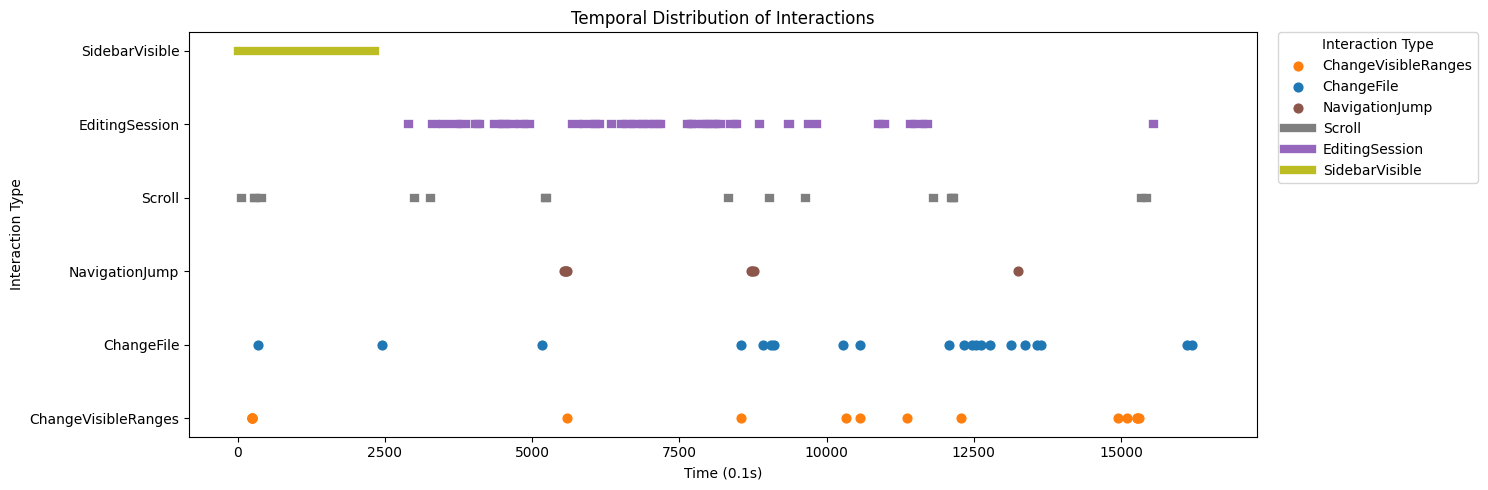


--- Participant P2 ---

Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'ChangeFile': 27, 'Scroll': 52, 'ChangeVisibleRanges': 43, 'UnknownJump': 17, 'EditingSession': 38, 'EditFile': 16, 'NavigationJump': 2})
Scrolling Distance: 744
Duration: 1463.525


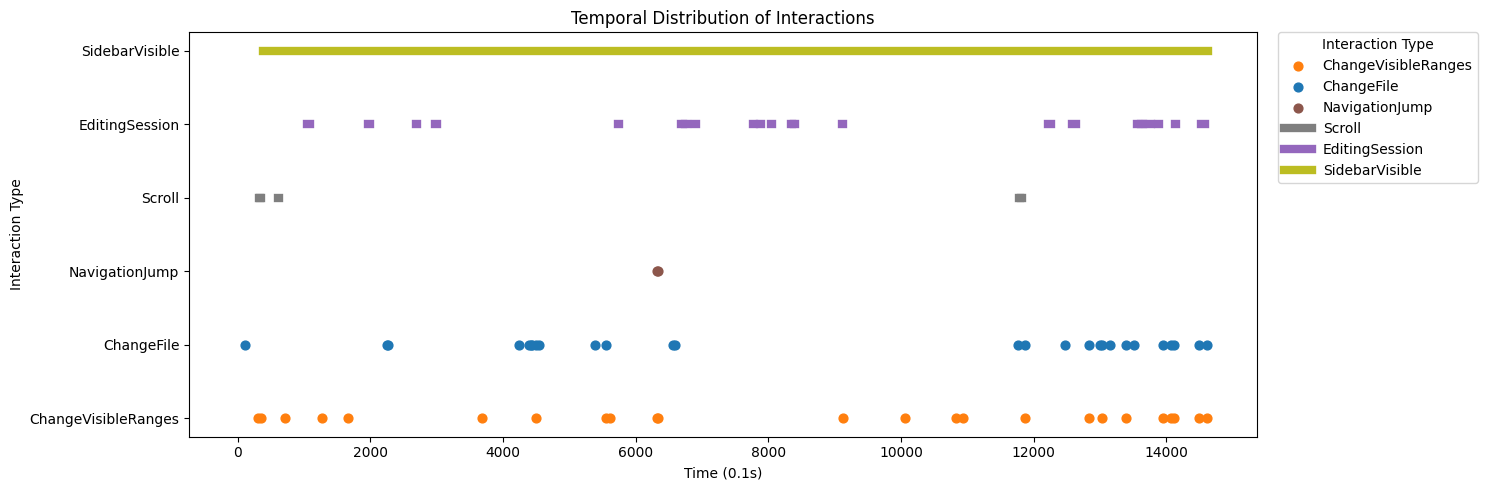


--- Participant P3 ---

Task Two
defaultdict(<class 'int'>, {'EditFile': 18, 'EditingSession': 54, 'ChangeFile': 47, 'ChangeVisibleRanges': 226, 'Scroll': 233, 'UnknownJump': 1822, 'ChangeSidebarVisibility': 3, 'NavigationJump': 4})
Scrolling Distance: 4808
Duration: 1611.695


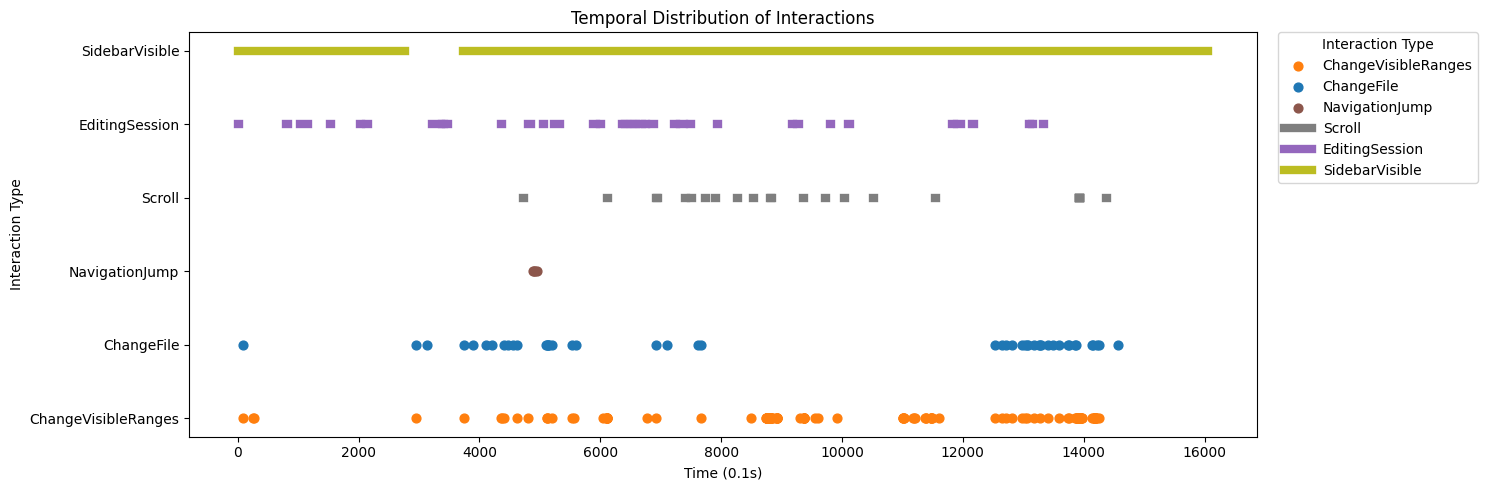


--- Participant P4 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 5, 'ChangeVisibleRanges': 11, 'Scroll': 133, 'NavigationJump': 18, 'UnknownJump': 1, 'EditingSession': 43, 'EditFile': 6})
Scrolling Distance: 986
Duration: 959.115


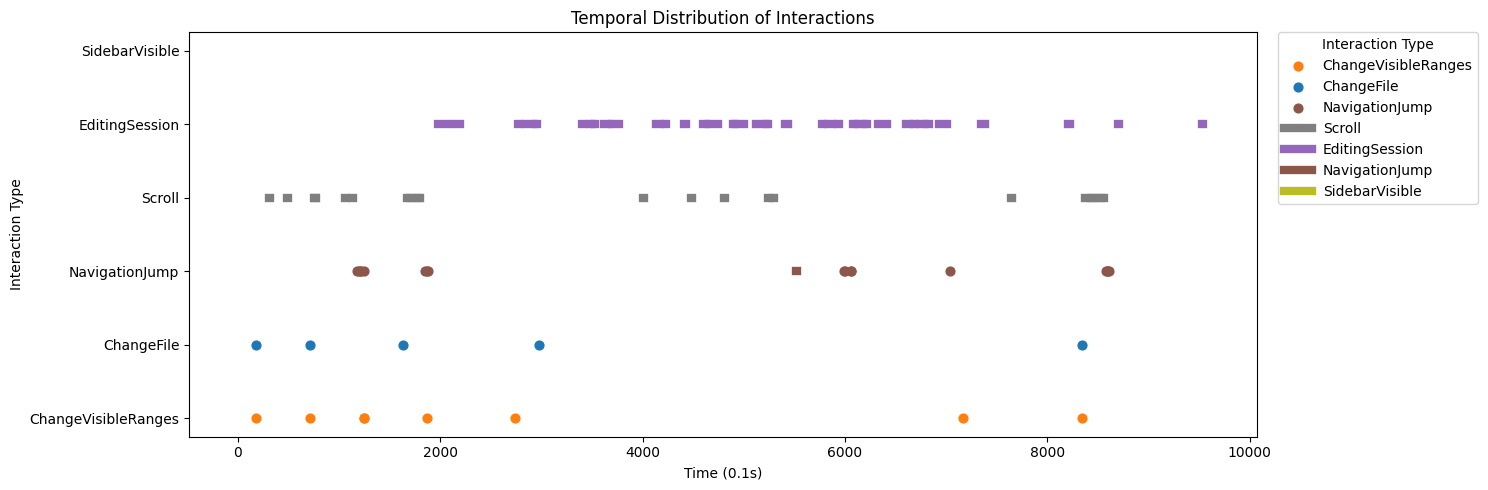


--- Participant P5 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 41, 'ChangeVisibleRanges': 76, 'Scroll': 164, 'EditingSession': 14, 'EditFile': 15, 'UnknownJump': 6})
Scrolling Distance: 1580
Duration: 1544.923


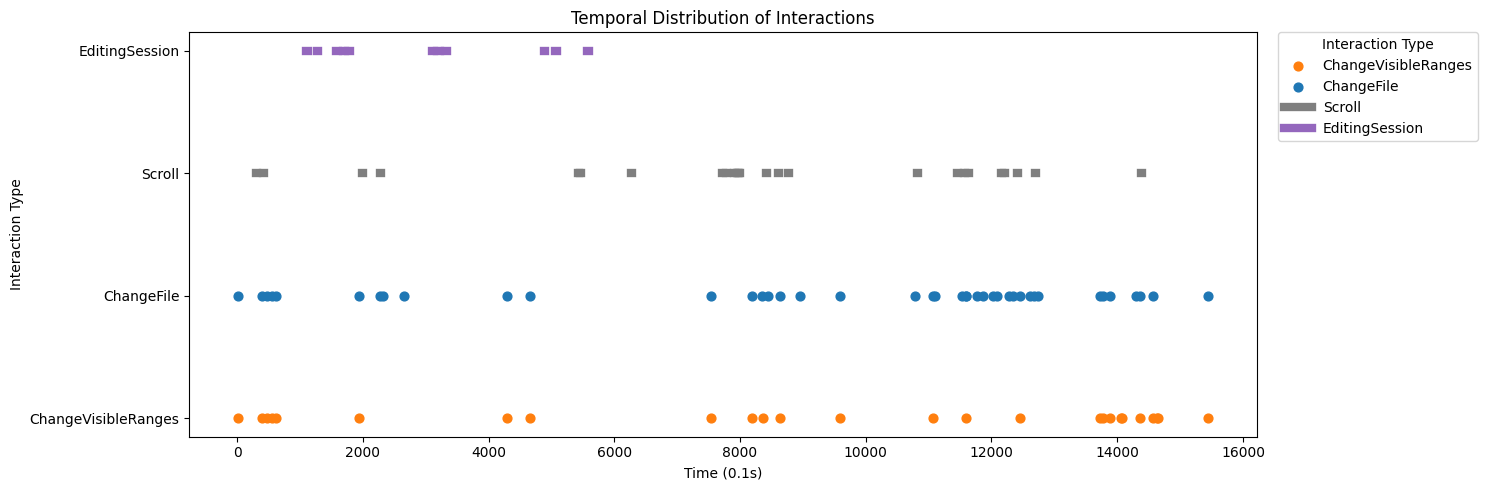


Task Two
defaultdict(<class 'int'>, {'Scroll': 115, 'UnknownJump': 4, 'ChangeVisibleRanges': 58, 'ChangeSidebarVisibility': 1, 'ChangeFile': 46, 'EditingSession': 11, 'EditFile': 7})
Scrolling Distance: 1249
Duration: 1425.996


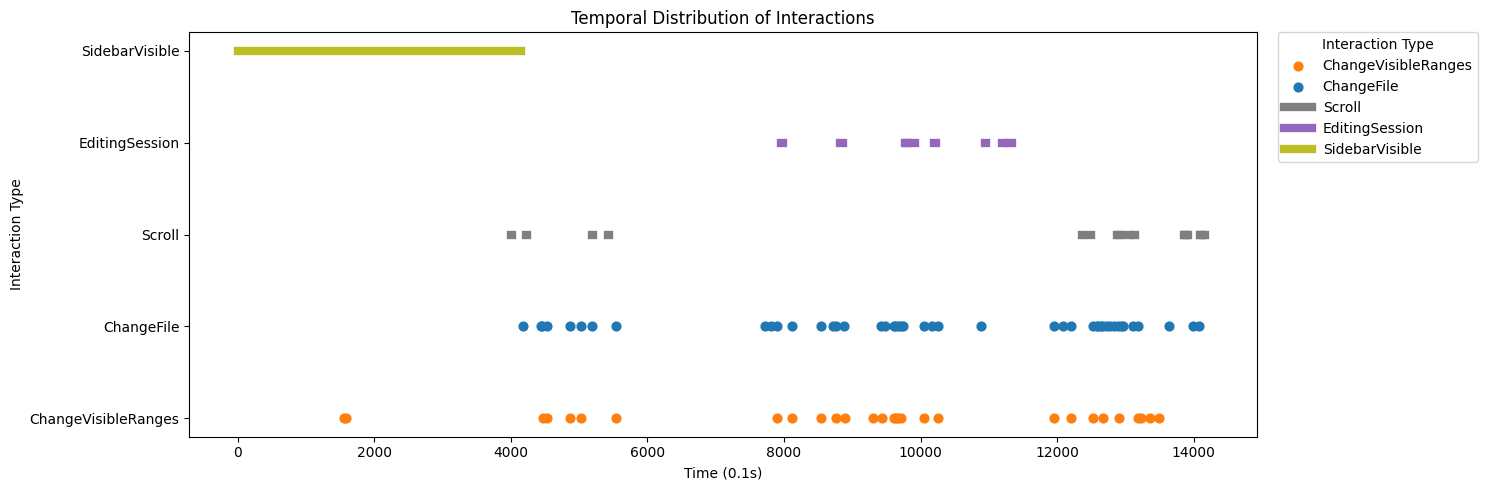


--- Participant P6 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'ChangeFile': 16, 'ChangeVisibleRanges': 24, 'Scroll': 145, 'EditingSession': 13, 'EditFile': 11, 'SwitchView': 2, 'UnknownJump': 7, 'NavigationJump': 4})
Scrolling Distance: 1444
Duration: 928.31


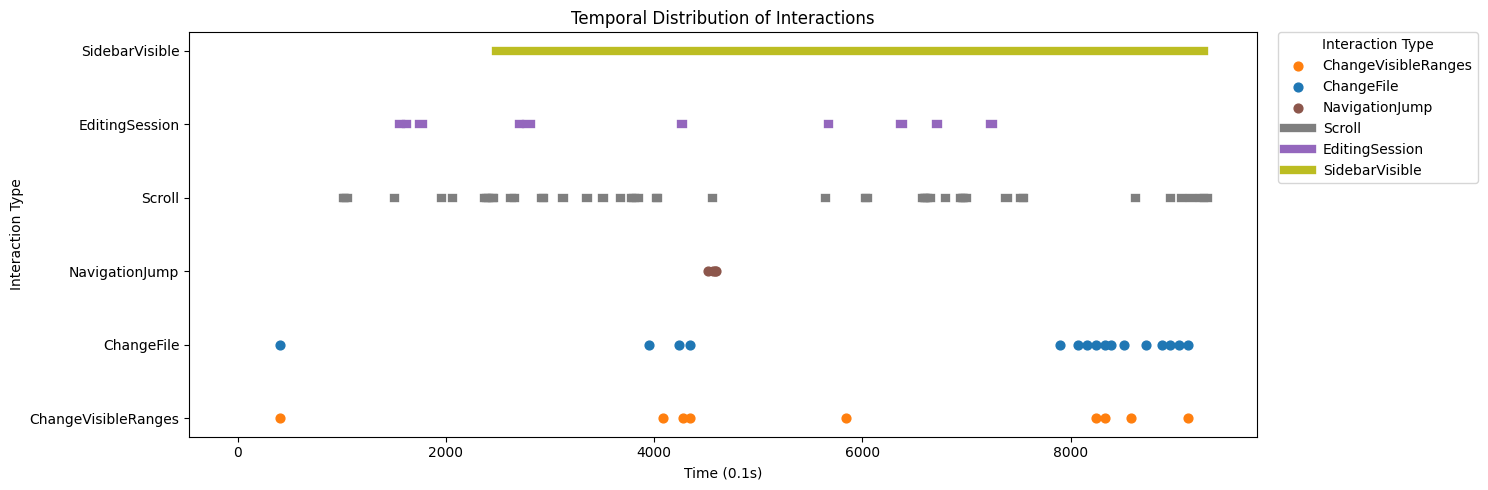


Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'Scroll': 97, 'ChangeFile': 29, 'UnknownJump': 9, 'ChangeVisibleRanges': 49, 'EditingSession': 42, 'EditFile': 21})
Scrolling Distance: 719
Duration: 1497.418


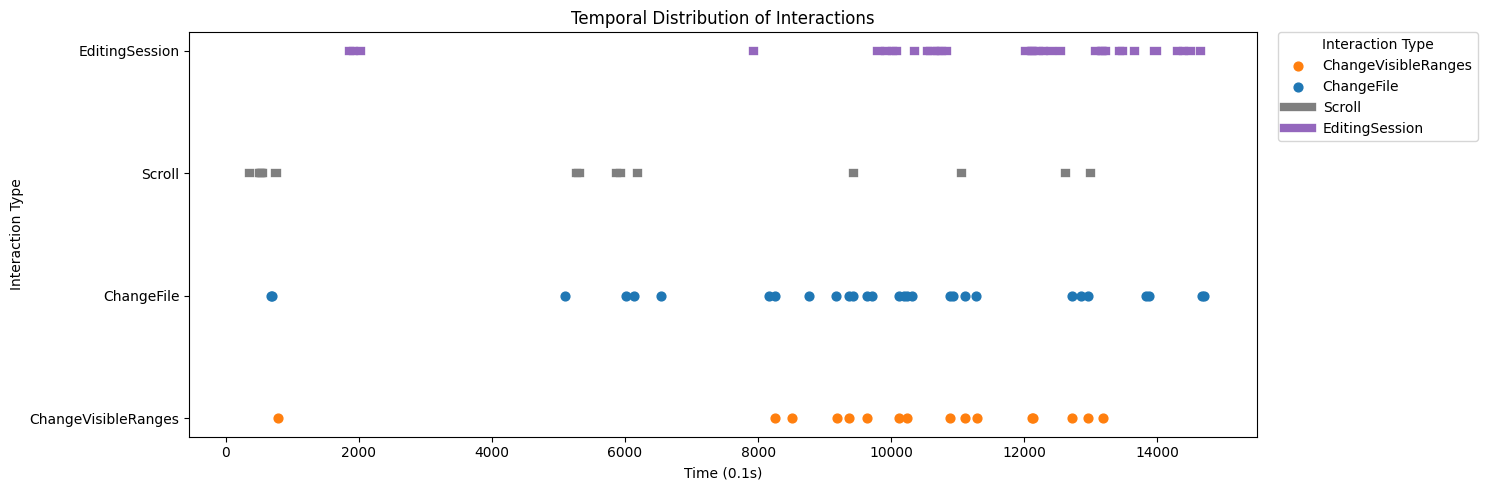


--- Participant P7 ---

Task One
defaultdict(<class 'int'>, {'Scroll': 150, 'ChangeFile': 14, 'ChangeVisibleRanges': 49, 'ChangeSidebarVisibility': 6, 'EditingSession': 23, 'EditFile': 11, 'UnknownJump': 2, 'NavigationJump': 8})
Scrolling Distance: 1675
Duration: 856.019


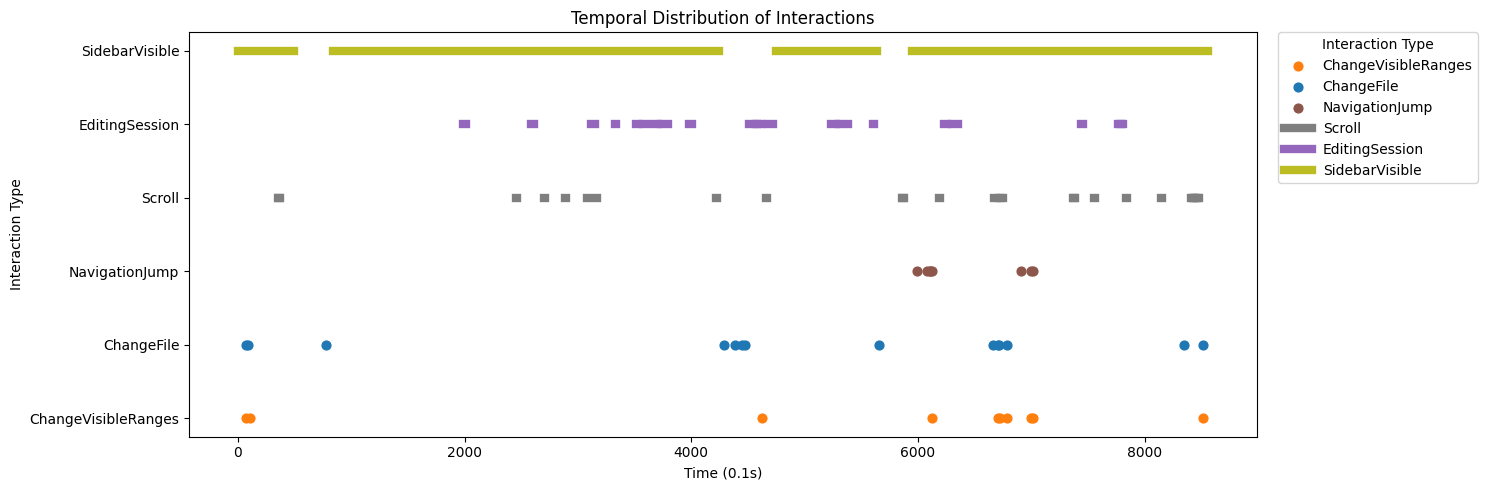


Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeVisibleRanges': 142, 'Scroll': 322, 'ChangeFile': 11, 'UnknownJump': 48, 'EditingSession': 32, 'EditFile': 10})
Scrolling Distance: 4410
Duration: 1761.019


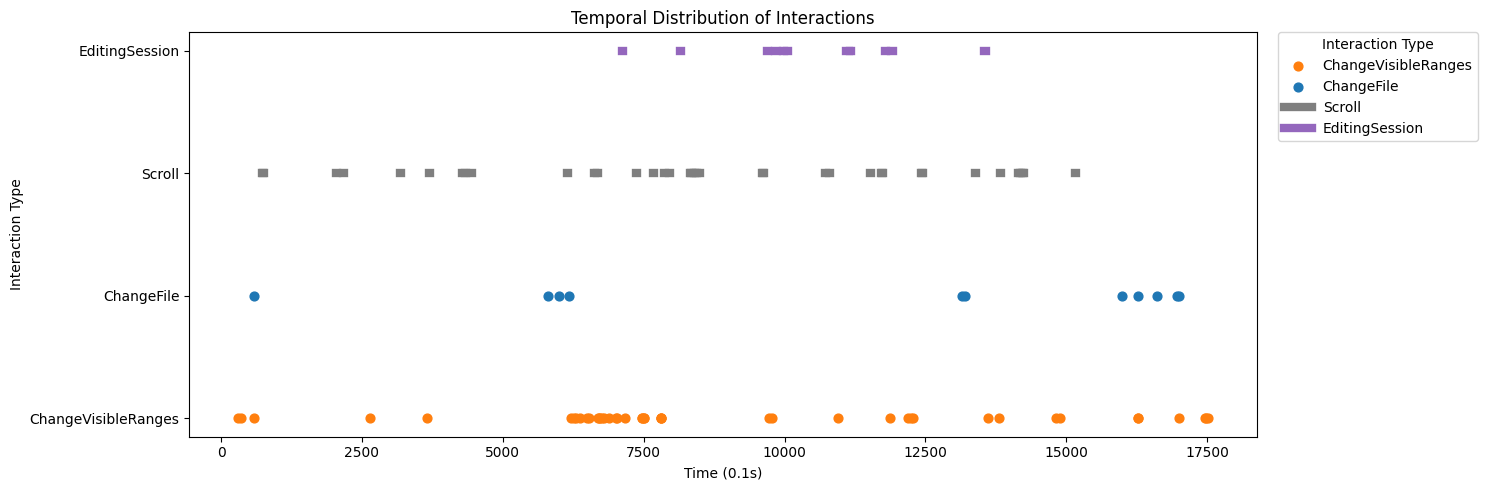


--- Participant P8 ---

Task One
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 27, 'ChangeVisibleRanges': 34, 'Scroll': 64, 'EditingSession': 29, 'EditFile': 9, 'UnknownJump': 5})
Scrolling Distance: 1109
Duration: 890.718


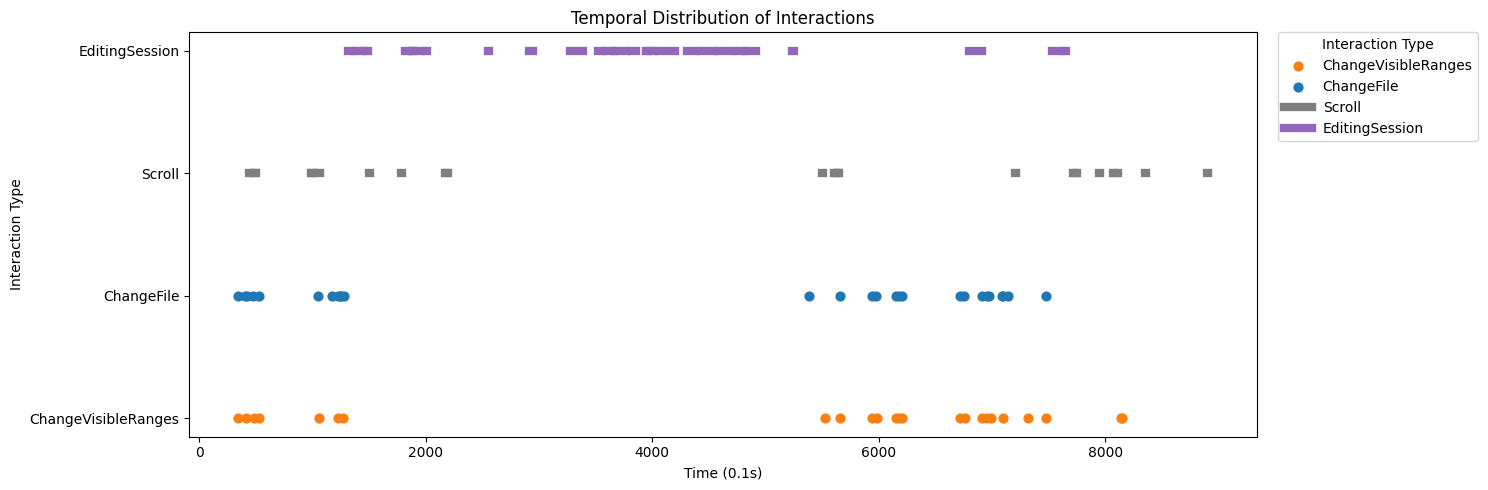


Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 1, 'ChangeFile': 60, 'ChangeVisibleRanges': 78, 'UnknownJump': 26, 'EditingSession': 53, 'Scroll': 40, 'EditFile': 24, 'NavigationJump': 3})
Scrolling Distance: 387
Duration: 1579.351


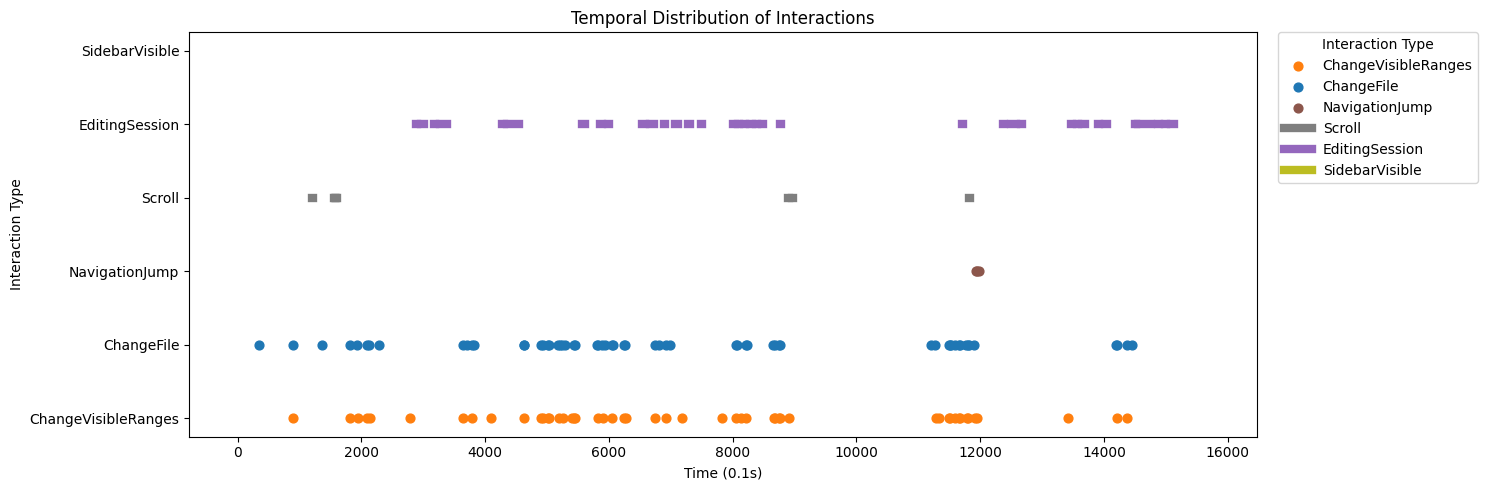


--- Participant P9 ---

Task One
defaultdict(<class 'int'>, {'Scroll': 7, 'ChangeVisibleRanges': 5, 'NavigationJump': 21, 'ChangeFile': 2, 'EditingSession': 2, 'ChangeSidebarVisibility': 1})
Scrolling Distance: 272
Duration: 984.207


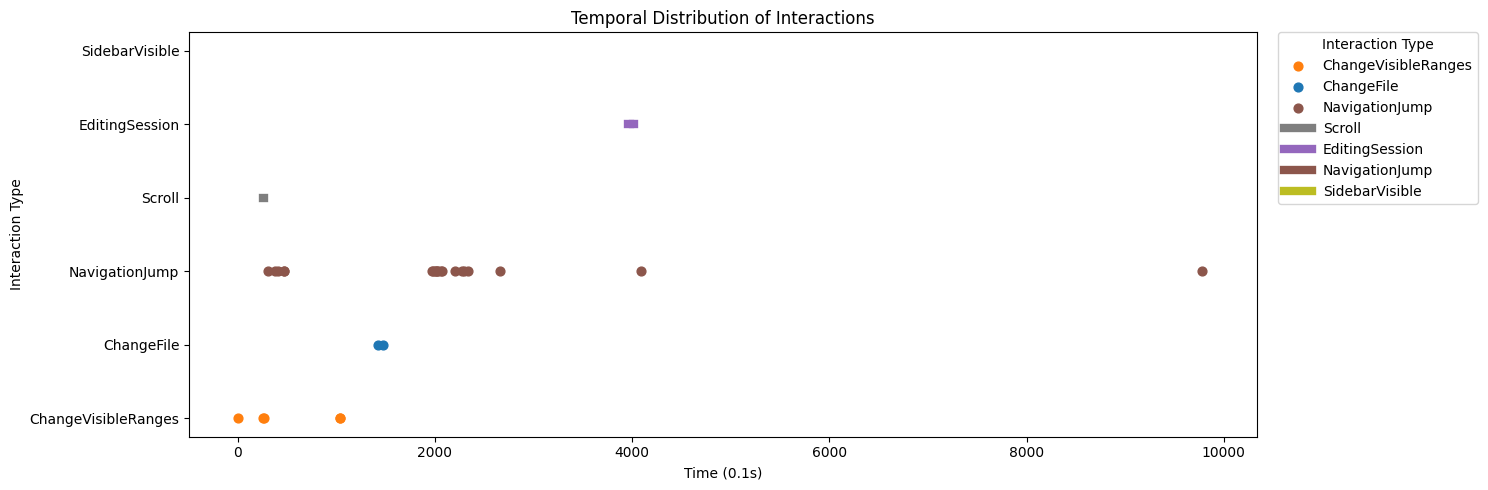


Task Two
defaultdict(<class 'int'>, {'ChangeSidebarVisibility': 2, 'Scroll': 94, 'SwitchView': 1, 'UnknownJump': 24, 'ChangeVisibleRanges': 5, 'EditingSession': 1, 'EditFile': 1, 'NavigationJump': 1})
Scrolling Distance: 1922
Duration: 959.392


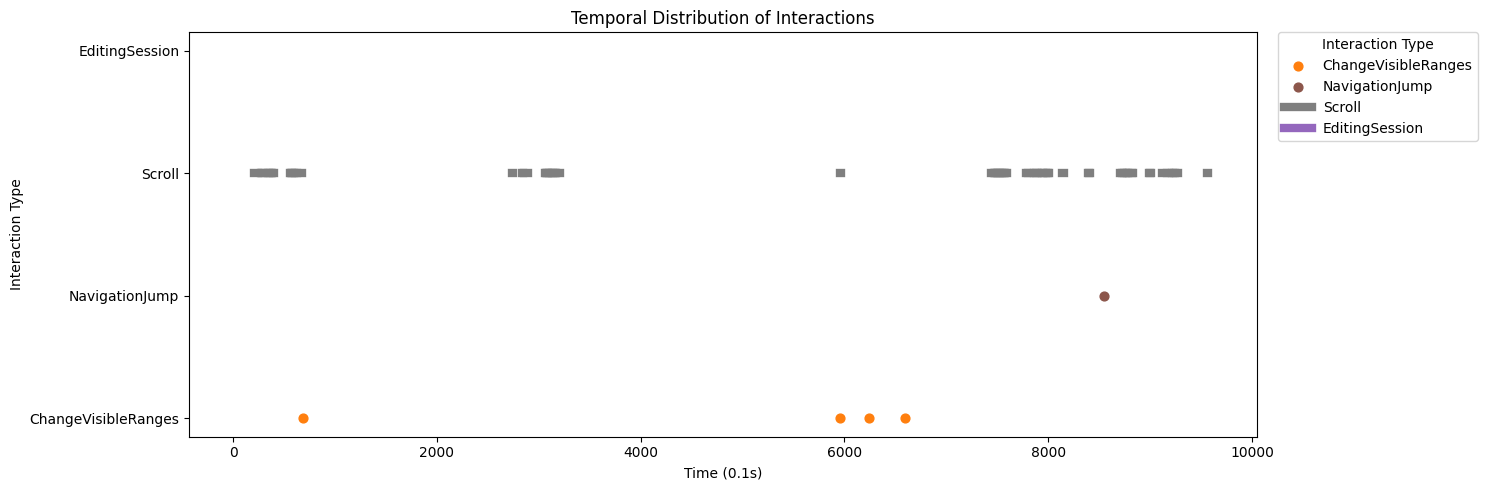

In [4]:
from interactions.plotting import plot_interactions

for participant in participants:
    print("\n--- Participant " + participant.name + " ---")

    if participant.interactionsTaskOne:
        print("\nTask One")
        print(countInteractions(participant.interactionsTaskOne))
        print(f"Scrolling Distance: {getScrollingDistance(participant.interactionsTaskOne)}")
        print(f"Duration: {(participant.interactionsTaskOne[-1]['timeStamp'] - participant.interactionsTaskOne[0]['timeStamp']) / 1000}")
        plot_interactions(participant.interactionsTaskOne, participant.evalTask == EvaluationTask.T1)

    if participant.interactionsTaskTwo:
        print("\nTask Two")
        print(countInteractions(participant.interactionsTaskTwo))
        print(f"Scrolling Distance: {getScrollingDistance(participant.interactionsTaskTwo)}")
        print(f"Duration: {(participant.interactionsTaskTwo[-1]['timeStamp'] - participant.interactionsTaskTwo[0]['timeStamp']) / 1000}")
        plot_interactions(participant.interactionsTaskTwo, participant.evalTask == EvaluationTask.T2)